In [15]:
import os
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import itertools
from scipy import stats
import matplotlib.cm as cm
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
from Helpers import *

In [16]:
df_cancelled_complete = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Cancelled operations.csv", sep=';')
df_complete_complete = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Completed operations.csv", sep = ';')

/var/folders/p9/p8xtbn1s27v69xbxcl4dpgtc0000gn/T/ipykernel_98809/383169137.py:2: DtypeWarning: Columns (13,14,21,22,23,24,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_complete_complete = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Completed operations.csv", sep = ';')


In [17]:
df_complete, df_cancelled = load_clean_data()

In [18]:
df_complete.head()

,Case-ID Anonymous,Patient Alder,Speciale,Stue,Operationsgang ID,Akut case (J/N),Dato,Pt ankommet til hospitalet,Planlagt stue klargøring start,Stue klargøring start,...,Procedure start time,Akut_korrigeret,Individuel forsinkelse,Faktisk varighed,Planlagt varighed,Varighed afvigelse,Ugedag,Måned,Forsinkelse_fejl_flag,Tidligere aflyst
0,28,29,Øre-næse-hals,OPNORD 23.240 (H),107621,Nej,2024-03-07,2024-03-07 10:51:00,2024-03-07 12:05:00,2024-03-07 13:05:00,...,14.0,0,-59.0,66.0,151.0,-85.0,Thursday,3,False,0
1,197,60,Plastikkirurgi,OPNORD 13.114 (H),107621,Nej,2024-01-05,2024-01-05 12:44:00,2024-01-05 13:40:00,2024-01-05 13:48:00,...,14.0,0,22.0,49.0,55.0,-6.0,Friday,1,False,0
2,197,60,Plastikkirurgi,OPNORD 13.114 (H),107621,Nej,2024-01-05,2024-01-05 12:44:00,2024-01-05 13:40:00,2024-01-05 13:48:00,...,14.0,0,22.0,49.0,55.0,-6.0,Friday,1,False,0
3,230,12,Plastikkirurgi,OPNORD 13.110 (H),107621,Nej,2024-01-26,2024-01-26 08:15:00,2024-01-26 08:00:00,2024-01-26 08:16:00,...,8.0,0,-19.0,22.0,70.0,-48.0,Friday,1,False,0
4,238,57,Plastikkirurgi,OPNORD 301,107621,Nej,2024-10-01,2024-10-01 12:14:00,2024-10-01 12:45:00,2024-10-01 13:01:00,...,13.0,0,-15.0,21.0,55.0,-34.0,Tuesday,10,False,0


In [19]:
df_complete.columns

Index(['Case-ID Anonymous', 'Patient Alder', 'Speciale', 'Stue',
       'Operationsgang ID', 'Akut case (J/N)', 'Dato',
       'Pt ankommet til hospitalet', 'Planlagt stue klargøring start',
       'Stue klargøring start', 'Stue klargjort',
       'Patient på stuen (Planlagt)', 'Patient på stuen', 'Anæstesistart',
       'Anæstesi melder klar', 'Procedure start', 'Procedure slut',
       'Patient klar til afgang', 'Patient forlader stuen (Planlagt)',
       'Patient forlader stuen', 'Stue rengjort (Planlagt)',
       'Stue rengøring start', 'Stue rengjort', 'I opvågning', 'Anæstesistop',
       'Klar til udskrivelse efter opvågning', 'Patient forlader afdeling',
       'Forsinkelse (minutter)', 'Overskredet (minutter)', 'Forsinkelsesårsag',
       'Procedure - Tekst & ID', 'Aktionsdiagnose - Kode & tekst',
       'Aktionsdiagnose - Gruppe', 'Akut', 'Procedure start time',
       'Akut_korrigeret', 'Individuel forsinkelse', 'Faktisk varighed',
       'Planlagt varighed', 'Varighed afvig

In [20]:
df_cancelled.columns

Index(['Case-ID Anonymous', 'Dato og tid', 'Primær procedure - Tekst',
       'Aflyst efter operationsprogrammet er afsluttet?',
       'Aflyst på dagen for operationen? ', 'Aflysningsårsag',
       'Forventet varighed (min.)', 'Ombooket', 'Stue', 'Operationsgang ID'],
      dtype='object')

## Cascading Delay Analysis

Question: **Do delays accumulate throughout the day?**
i.e. is the 4th operation in a room systematically more delayed than the 1st?

Approach:
- Group operations by room () + day ()
- Only keep rows where the patient **actually entered the room** ( is not NaT)
- Sort by actual entry time within each group
- Assign a **position number** (1st, 2nd, 3rd op of the day in that room)
- Plot average  per position across all rooms and days

In [21]:
# Only keep operations where the patient actually entered the room
# (Patient på stuen is not NaT means the operation took place)
df_cascade = df_complete.dropna(subset=['Patient på stuen', 'Forsinkelse (minutter)']).copy()

# Normalise Dato to date only (no time component) for grouping
df_cascade['Dato_norm'] = df_cascade['Dato'].dt.normalize()

# Sort by room + day + actual entry time
df_cascade = df_cascade.sort_values(['Stue', 'Dato_norm', 'Patient på stuen'])

# Assign position number within each room-day group
df_cascade['Position'] = df_cascade.groupby(['Stue', 'Dato_norm']).cumcount() + 1

print(f'Operations included: {len(df_cascade):,}')
print(f'Max position in a single day/room: {df_cascade["Position"].max()}')
print(df_cascade[['Stue', 'Dato_norm', 'Patient på stuen', 'Forsinkelse (minutter)', 'Position']].head(10))

Operations included: 132,491
Max position in a single day/room: 19
                          Stue  Dato_norm    Patient på stuen  \
70904  AMBULANT OPERATION 8067 2024-01-11 2024-01-11 10:10:00   
70959  AMBULANT OPERATION 8067 2024-01-11 2024-01-11 10:54:00   
24643  AMBULANT OPERATION 8067 2024-01-11 2024-01-11 11:56:00   
24655  AMBULANT OPERATION 8067 2024-01-11 2024-01-11 13:02:00   
24735  AMBULANT OPERATION 8067 2024-02-08 2024-02-08 09:00:00   
24798  AMBULANT OPERATION 8067 2024-02-08 2024-02-08 10:01:00   
25132  AMBULANT OPERATION 8067 2024-04-04 2024-04-04 09:10:00   
802    AMBULANT OPERATION 8067 2024-05-07 2024-05-07 09:01:00   
24980  AMBULANT OPERATION 8067 2024-05-07 2024-05-07 10:11:00   
25025  AMBULANT OPERATION 8067 2024-05-07 2024-05-07 11:10:00   

       Forsinkelse (minutter)  Position  
70904                   -40.0         1  
70959                   -61.0         2  
24643                   -64.0         3  
24655                   -62.0         4  
24735  

In [23]:
# Only look at positions with enough observations to be meaningful
MIN_OBS = 50

position_stats = (
    df_cascade.groupby('Position')['Forsinkelse (minutter)']
    .agg(mean='mean', median='median', count='count', std='std')
    .reset_index()
)

# Filter to positions with enough data
position_stats = position_stats[position_stats['count'] >= MIN_OBS]

print(position_stats.to_string(index=False))

 Position      mean  median  count       std
        1 11.368325     9.0  46364 49.782443
        2 17.161027    13.0  34013 48.956318
        3 22.827583    19.0  20636 52.384688
        4 27.819125    24.0  12141 51.512143
        5 34.005475    33.0   7306 53.656057
        6 39.872614    40.0   4663 46.488436
        7 46.522453    49.0   2984 49.280960
        8 49.114627    52.0   1928 41.927729
        9 48.808858    50.0   1287 36.204244
       10 57.298527    61.0    747 33.088727
       11 62.013115    65.0    305 31.247523
       12 51.556962    52.0     79 37.335536


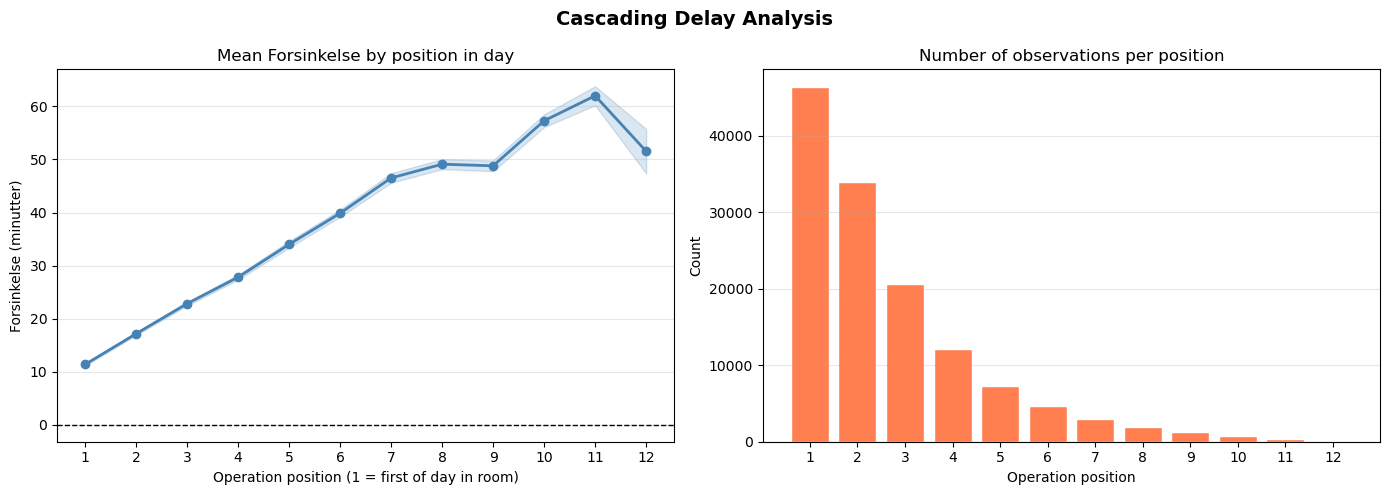

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Mean delay by position ---
axes[0].plot(position_stats['Position'], position_stats['mean'], marker='o', linewidth=2, color='steelblue')
axes[0].fill_between(
    position_stats['Position'],
    position_stats['mean'] - position_stats['std'] / position_stats['count'] ** 0.5,
    position_stats['mean'] + position_stats['std'] / position_stats['count'] ** 0.5,
    alpha=0.2, color='steelblue', label='95% CI'
)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Mean Forsinkelse by position in day')
axes[0].set_xlabel('Operation position (1 = first of day in room)')
axes[0].set_ylabel('Forsinkelse (minutter)')
axes[0].set_xticks(position_stats['Position'])
axes[0].grid(axis='y', alpha=0.3)

# --- Number of observations per position ---
axes[1].bar(position_stats['Position'], position_stats['count'], color='coral', edgecolor='white')
axes[1].set_title('Number of observations per position')
axes[1].set_xlabel('Operation position')
axes[1].set_ylabel('Count')
axes[1].set_xticks(position_stats['Position'])
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Cascading Delay Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Acute vs. Non-acute

Does the cascade look different on days with acute operations inserted?  
We split by  and plot both groups side by side.

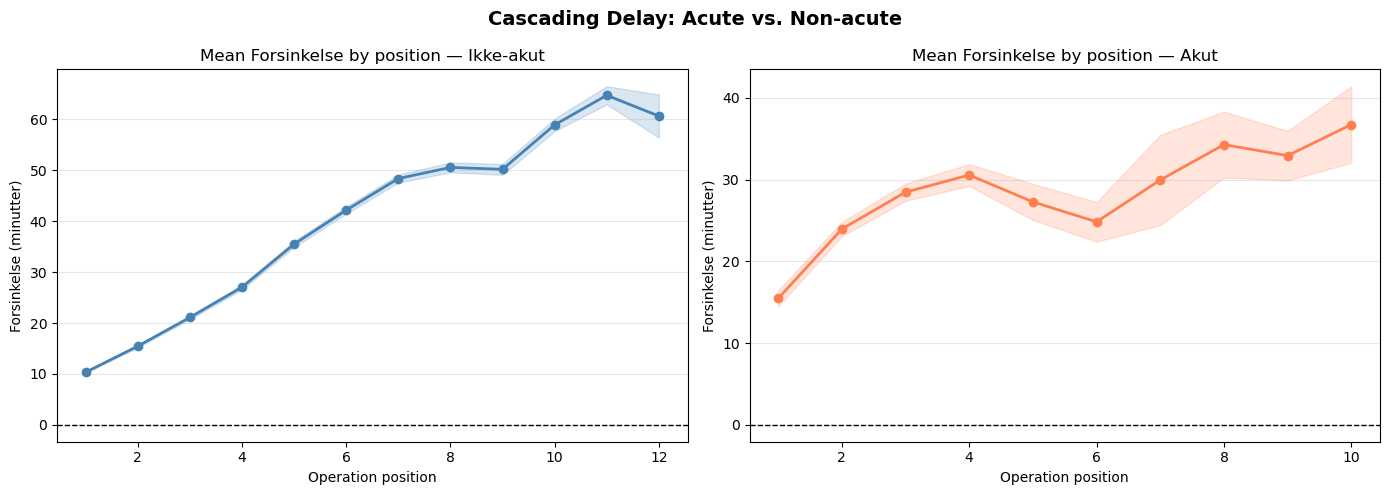

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, group) in zip(axes, df_cascade.groupby('Akut_korrigeret')):
    stats = (
        group.groupby('Position')['Forsinkelse (minutter)']
        .agg(mean='mean', count='count', std='std')
        .reset_index()
    )
    stats = stats[stats['count'] >= MIN_OBS]

    name = 'Akut' if label == 1 else 'Ikke-akut'
    color = 'coral' if label == 1 else 'steelblue'

    ax.plot(stats['Position'], stats['mean'], marker='o', linewidth=2, color=color)
    ax.fill_between(
        stats['Position'],
        stats['mean'] - stats['std'] / stats['count'] ** 0.5,
        stats['mean'] + stats['std'] / stats['count'] ** 0.5,
        alpha=0.2, color=color
    )
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'Mean Forsinkelse by position — {name}')
    ax.set_xlabel('Operation position')
    ax.set_ylabel('Forsinkelse (minutter)')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cascading Delay: Acute vs. Non-acute', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Planlagt tid per delproces per speciale

Vi beregner hvor lang tid der er planlagt til hver delproces i en operation, opdelt per speciale.

**Delprocesserne er:**
1. **Stue klargøring** — fra  → 
2. **Operations slot** — fra  → 
3. **Stue rengøring** — fra  → 

Disse tre dækker hele det planlagte forløb for en stue fra klargøring til rengøring er færdig.

> **Bemærk:** Vi bruger medianen fremfor gennemsnittet, da fordelingen er skæv (enkelte meget lange operationer trækker gennemsnittet op).

In [26]:
# Beregn planlagt varighed for hver delproces (i minutter)
# Vi laver en kopi så vi ikke roder med df_complete
df_del = df_complete.copy()

# Delproces 1: Stue klargøring
# Fra planlagt klargøring starter til patienten er planlagt på stuen
df_del['Del1_Stue_klargøring'] = (
    df_del['Patient på stuen (Planlagt)'] - df_del['Planlagt stue klargøring start']
).dt.total_seconds() / 60

# Delproces 2: Operations slot
# Fra patienten er planlagt på stuen til patienten er planlagt til at forlade stuen
# Dette inkluderer anæstesi + selve proceduren + afgang fra stue
df_del['Del2_Operations_slot'] = (
    df_del['Patient forlader stuen (Planlagt)'] - df_del['Patient på stuen (Planlagt)']
).dt.total_seconds() / 60

# Delproces 3: Stue rengøring
# Fra patienten er planlagt til at forlade stuen til stuen er planlagt rengjort
df_del['Del3_Stue_rengøring'] = (
    df_del['Stue rengjort (Planlagt)'] - df_del['Patient forlader stuen (Planlagt)']
).dt.total_seconds() / 60

# Fjern urealistiske værdier (negative eller ekstremt lange — sandsynligvis fejlregistreringer)
for col in ['Del1_Stue_klargøring', 'Del2_Operations_slot', 'Del3_Stue_rengøring']:
    df_del.loc[df_del[col] < 0, col] = None
    df_del.loc[df_del[col] > 600, col] = None  # mere end 10 timer er urealistisk

# Overblik over de beregnede delprocesser
print(df_del[['Del1_Stue_klargøring', 'Del2_Operations_slot', 'Del3_Stue_rengøring']].describe().round(1))

       Del1_Stue_klargøring  Del2_Operations_slot  Del3_Stue_rengøring
count              132735.0              132620.0             132735.0
mean                    3.0                 111.5                  8.9
std                     6.6                  92.7                 10.1
min                     0.0                   6.0                  0.0
25%                     0.0                  44.0                  0.0
50%                     0.0                  90.0                 10.0
75%                     0.0                 149.0                 15.0
max                    90.0                 600.0                 90.0


In [27]:
# Beregn median per speciale for hver delproces
delprocess_cols = ['Del1_Stue_klargøring', 'Del2_Operations_slot', 'Del3_Stue_rengøring']

median_per_speciale = (
    df_del.groupby('Speciale')[delprocess_cols]
    .median()
    .round(1)
    .rename(columns={
        'Del1_Stue_klargøring': 'Stue klargøring (min)',
        'Del2_Operations_slot': 'Operations slot (min)',
        'Del3_Stue_rengøring':  'Stue rengøring (min)'
    })
)

# Tilføj en total kolonne
median_per_speciale['Total (min)'] = median_per_speciale.sum(axis=1)

print(median_per_speciale.sort_values('Total (min)', ascending=False).to_string())

                                Stue klargøring (min)  Operations slot (min)  Stue rengøring (min)  Total (min)
Speciale                                                                                                       
Brystkirurgi                                      0.0                  390.0                  30.0        420.0
Hjertekirurgi                                    20.0                  309.0                  30.0        359.0
Alloplastik                                       0.0                  210.0                   0.0        210.0
Rygkirurgi                                        0.0                  170.0                  20.0        190.0
Ortopædkirurgi                                    0.0                  167.0                   0.0        167.0
Tumorortopædi                                     0.0                  150.0                  15.0        165.0
Kirurgi                                           0.0                  151.0                   0.0      

### Interaktivt plot

Vælg et speciale i dropdown-menuen for at se fordelingen af planlagt tid per delproces.
Plottet viser en **stacked bar** med de tre delprocesser, samt boxplots der viser spredningen.

In [28]:
import ipywidgets as widgets
from IPython.display import display

delprocess_cols = [
    'Del1_Stue_klargøring',
    'Del2_Operations_slot',
    'Del3_Stue_rengøring'
]
delprocess_labels = [
    'Stue klargøring',
    'Operations slot',
    'Stue rengøring'
]
colors = ['#4C9BE8', '#E87B4C', '#4CE882']

specialer = ['Alle'] + sorted(df_del['Speciale'].dropna().unique().tolist())

def plot_delprocesser(speciale):
    if speciale == 'Alle':
        df_plot = df_del
    else:
        df_plot = df_del[df_del['Speciale'] == speciale]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Venstre: Stacked bar med median per delproces ---
    medians = [df_plot[col].median() for col in delprocess_cols]
    total = sum(m for m in medians if pd.notna(m))

    bottom = 0
    for label, median, color in zip(delprocess_labels, medians, colors):
        if pd.notna(median):
            axes[0].bar(0, median, bottom=bottom, color=color, label=f'{label} ({median:.0f} min)', width=0.4)
            axes[0].text(0, bottom + median / 2, f'{median:.0f} min', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
            bottom += median

    axes[0].set_title(f'Planlagt tid per delproces\n{speciale} — total: {total:.0f} min')
    axes[0].set_ylabel('Minutter')
    axes[0].set_xticks([])
    axes[0].legend(loc='upper right', fontsize=9)
    axes[0].grid(axis="y", alpha=0.3)

    # --- Højre: Boxplot for at se spredning ---
    data_to_plot = [df_plot[col].dropna().values for col in delprocess_cols]
    bp = axes[1].boxplot(data_to_plot, labels=delprocess_labels, patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1].set_title(f'Spredning i planlagt tid per delproces\n{speciale}')
    axes[1].set_ylabel('Minutter')
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

dropdown = widgets.Dropdown(
    options=specialer,
    value='Alle',
    description='Speciale:'
)

output = widgets.interactive_output(plot_delprocesser, {'speciale': dropdown})
display(dropdown, output)

SyntaxError: unterminated f-string literal (detected at line 37) (758147533.py, line 37)

In [29]:
import plotly.express as px

# Lav long-format dataframe til plotly
# Vi beregner median per speciale for hver delproces
delprocess_cols = ['Del1_Stue_klargøring', 'Del2_Operations_slot', 'Del3_Stue_rengøring']

median_per_speciale = (
    df_del.groupby('Speciale')[delprocess_cols]
    .median()
    .round(1)
    .rename(columns={
        'Del1_Stue_klargøring': 'Stue klargøring',
        'Del2_Operations_slot': 'Operations slot',
        'Del3_Stue_rengøring':  'Stue rengøring'
    })
    .reset_index()
)

# Konverter til long format (en række per speciale per delproces)
eff_long = median_per_speciale.melt(
    id_vars='Speciale',
    value_vars=['Stue klargøring', 'Operations slot', 'Stue rengøring'],
    var_name='phase',
    value_name='minutes'
)

# Sorter specialerne efter total planlagt tid (længste øverst)
order = (
    eff_long.groupby('Speciale')['minutes']
    .sum()
    .sort_values(ascending=False)
    .index.tolist()
)

fig = px.bar(
    eff_long,
    x='Speciale',
    y='minutes',
    color='phase',
    category_orders={'Speciale': order},
    color_discrete_map={
        'Stue klargøring': '#4C9BE8',
        'Operations slot': '#E87B4C',
        'Stue rengøring':  '#4CE882'
    },
    title='Planlagt tid per delproces pr. speciale (median)',
    barmode='stack'
)

fig.update_layout(
    xaxis_title='Speciale',
    yaxis_title='Median minutter',
    xaxis_tickangle=-45,
    legend_title='Delproces',
    height=550
)

fig.show()

## Planlagt vs. Faktisk vs. Forsinkelse per delproces

Tre plots der tilsammen fortæller en sammenhængende historie:

- **Plot 1** — Hvad er *allokeret* (planlagt tid per delproces)
- **Plot 2** — Hvad *sker der faktisk* (faktisk tid per delproces)
- **Plot 3** — Hvor er *gabet* (faktisk minus planlagt per delproces)

### Delprocesser
| | Planlagt | Faktisk |
|---|---|---|
| Stue klargøring |  →  |  →  |
| Anæstesi + patient klar | del af operations slot |  →  |
| Selve operation | del af operations slot |  →  |
| Afgang fra stue | del af operations slot |  →  |
| Stue rengøring |  →  |  →  |

> **Bemærk:** Da vi kun har ét samlet planlagt interval for selve operationen (operations slot), sammenligner vi det med summen af anæstesi + operation + afgang fra stue.

In [ ]:
# ================================================================
# BEREGN PLANLAGTE VARIGHEDER
# ================================================================
df_trefold = df_complete.copy()

# Planlagt stue klargøring
df_trefold['Plan_klargøring'] = (
    df_trefold['Patient på stuen (Planlagt)'] - df_trefold['Planlagt stue klargøring start']
).dt.total_seconds() / 60

# Planlagt operations slot (anæstesi + operation + afgang — ét samlet interval)
df_trefold['Plan_operations_slot'] = (
    df_trefold['Patient forlader stuen (Planlagt)'] - df_trefold['Patient på stuen (Planlagt)']
).dt.total_seconds() / 60

# Planlagt stue rengøring
df_trefold['Plan_rengøring'] = (
    df_trefold['Stue rengjort (Planlagt)'] - df_trefold['Patient forlader stuen (Planlagt)']
).dt.total_seconds() / 60

# ================================================================
# BEREGN FAKTISKE VARIGHEDER
# ================================================================

# Faktisk stue klargøring
df_trefold['Fakt_klargøring'] = (
    df_trefold['Stue klargjort'] - df_trefold['Stue klargøring start']
).dt.total_seconds() / 60

# Faktisk anæstesi forberedelse (patient på stue → procedure starter)
df_trefold['Fakt_anæstesi'] = (
    df_trefold['Procedure start'] - df_trefold['Patient på stuen']
).dt.total_seconds() / 60

# Faktisk operations tid
df_trefold['Fakt_operation'] = (
    df_trefold['Procedure slut'] - df_trefold['Procedure start']
).dt.total_seconds() / 60

# Faktisk afgang fra stue (procedure slut → patient forlader stuen)
df_trefold['Fakt_afgang'] = (
    df_trefold['Patient forlader stuen'] - df_trefold['Procedure slut']
).dt.total_seconds() / 60

# Faktisk stue rengøring
df_trefold['Fakt_rengøring'] = (
    df_trefold['Stue rengjort'] - df_trefold['Stue rengøring start']
).dt.total_seconds() / 60

# Faktisk operations slot total (til sammenligning med planlagt)
df_trefold['Fakt_operations_slot'] = (
    df_trefold['Fakt_anæstesi'] + df_trefold['Fakt_operation'] + df_trefold['Fakt_afgang']
)

# Fjern urealistiske værdier
alle_cols = [
    'Plan_klargøring', 'Plan_operations_slot', 'Plan_rengøring',
    'Fakt_klargøring', 'Fakt_anæstesi', 'Fakt_operation',
    'Fakt_afgang', 'Fakt_rengøring', 'Fakt_operations_slot'
]
for col in alle_cols:
    df_trefold.loc[df_trefold[col] < 0,   col] = None
    df_trefold.loc[df_trefold[col] > 600, col] = None

print("Planlagte delprocesser — median (minutter):")
print(df_trefold[['Plan_klargøring', 'Plan_operations_slot', 'Plan_rengøring']].median().round(1))
print()
print("Faktiske delprocesser — median (minutter):")
print(df_trefold[['Fakt_klargøring', 'Fakt_anæstesi', 'Fakt_operation', 'Fakt_afgang', 'Fakt_rengøring']].median().round(1))

### Plot 1 — Hvad er allokeret (planlagt)?

In [ ]:
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

specialer = ['Alle'] + sorted(df_trefold['Speciale'].dropna().unique().tolist())

plan_cols   = ['Plan_klargøring', 'Plan_operations_slot', 'Plan_rengøring']
plan_labels = ['Stue klargøring', 'Operations slot', 'Stue rengøring']

def plot_planlagt(speciale):
    df_p = df_trefold if speciale == 'Alle' else df_trefold[df_trefold['Speciale'] == speciale]

    rows = []
    for col, label in zip(plan_cols, plan_labels):
        rows.append({'Delproces': label, 'Minutter': df_p[col].median()})

    import pandas as pd
    df_fig = pd.DataFrame(rows)
    total = df_fig['Minutter'].sum()

    fig = px.bar(
        df_fig, x='Delproces', y='Minutter',
        color='Delproces',
        color_discrete_sequence=['#4C9BE8', '#E87B4C', '#4CE882'],
        title=f'Plot 1 — Planlagt tid per delproces ({speciale}) — Total: {total:.0f} min',
        text='Minutter'
    )
    fig.update_traces(texttemplate='%{text:.0f} min', textposition='inside')
    fig.update_layout(yaxis_title='Median minutter', showlegend=False, height=450)
    fig.show()

dropdown1 = widgets.Dropdown(options=specialer, value='Alle', description='Speciale:')
out1 = widgets.interactive_output(plot_planlagt, {'speciale': dropdown1})
display(dropdown1, out1)

### Plot 2 — Hvad sker der faktisk?

In [ ]:
fakt_cols   = ['Fakt_klargøring', 'Fakt_anæstesi', 'Fakt_operation', 'Fakt_afgang', 'Fakt_rengøring']
fakt_labels = ['Stue klargøring', 'Anæstesi forberedelse', 'Selve operation', 'Afgang fra stue', 'Stue rengøring']

def plot_faktisk(speciale):
    df_p = df_trefold if speciale == 'Alle' else df_trefold[df_trefold['Speciale'] == speciale]

    rows = []
    for col, label in zip(fakt_cols, fakt_labels):
        rows.append({'Delproces': label, 'Minutter': df_p[col].median()})

    import pandas as pd
    df_fig = pd.DataFrame(rows).dropna()
    total = df_fig['Minutter'].sum()

    fig = px.bar(
        df_fig, x='Delproces', y='Minutter',
        color='Delproces',
        color_discrete_sequence=['#4C9BE8', '#6A4CE8', '#E87B4C', '#E8C44C', '#4CE882'],
        title=f'Plot 2 — Faktisk tid per delproces ({speciale}) — Total: {total:.0f} min',
        text='Minutter'
    )
    fig.update_traces(texttemplate='%{text:.0f} min', textposition='inside')
    fig.update_layout(yaxis_title='Median minutter', showlegend=False, height=450)
    fig.show()

dropdown2 = widgets.Dropdown(options=specialer, value='Alle', description='Speciale:')
out2 = widgets.interactive_output(plot_faktisk, {'speciale': dropdown2})
display(dropdown2, out2)

### Plot 3 — Hvor er gabet? (faktisk minus planlagt)

Vi sammenligner de delprocesser vi kan matche direkte:
- **Stue klargøring**: planlagt vs. faktisk
- **Operations slot**: planlagt vs. faktisk (anæstesi + operation + afgang)
- **Stue rengøring**: planlagt vs. faktisk

En **positiv** søjle betyder at det tog *længere* end planlagt.  
En **negativ** søjle betyder at det gik *hurtigere* end planlagt.

In [ ]:
def plot_forsinkelse(speciale):
    df_p = df_trefold if speciale == 'Alle' else df_trefold[df_trefold['Speciale'] == speciale]

    gaps = {
        'Stue klargøring':  df_p['Fakt_klargøring'].median()    - df_p['Plan_klargøring'].median(),
        'Operations slot':  df_p['Fakt_operations_slot'].median() - df_p['Plan_operations_slot'].median(),
        'Stue rengøring':   df_p['Fakt_rengøring'].median()      - df_p['Plan_rengøring'].median(),
    }

    import pandas as pd
    df_fig = pd.DataFrame(list(gaps.items()), columns=['Delproces', 'Gap (min)'])

    # Farve: rød = løb over, grøn = hurtigere end planlagt
    df_fig['Farve'] = df_fig['Gap (min)'].apply(lambda x: 'Løb over' if x > 0 else 'Hurtigere end planlagt')

    fig = px.bar(
        df_fig, x='Delproces', y='Gap (min)',
        color='Farve',
        color_discrete_map={'Løb over': '#E84C4C', 'Hurtigere end planlagt': '#4CE882'},
        title=f'Plot 3 — Gab mellem faktisk og planlagt tid ({speciale})',
        text='Gap (min)'
    )
    fig.update_traces(texttemplate='%{text:.1f} min', textposition='outside')
    fig.add_hline(y=0, line_dash='dash', line_color='black')
    fig.update_layout(yaxis_title='Faktisk minus planlagt (minutter)', height=450)
    fig.show()

dropdown3 = widgets.Dropdown(options=specialer, value='Alle', description='Speciale:')
out3 = widgets.interactive_output(plot_forsinkelse, {'speciale': dropdown3})
display(dropdown3, out3)

In [32]:
df_cancelled['Primær procedure - Tekst'].nunique()

135

In [33]:
df_complete['Procedure - Tekst & ID'].nunique()

2278

In [34]:
df_complete.head()
df_complete.columns
df_complete.info()
df_complete.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133158 entries, 0 to 133157
Data columns (total 44 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   Case-ID Anonymous                     133158 non-null  int64         
 1   Patient Alder                         133158 non-null  int64         
 2   Speciale                              133158 non-null  object        
 3   Stue                                  133038 non-null  object        
 4   Operationsgang ID                     133158 non-null  int64         
 5   Akut case (J/N)                       133158 non-null  object        
 6   Dato                                  133158 non-null  datetime64[ns]
 7   Pt ankommet til hospitalet            132661 non-null  datetime64[ns]
 8   Planlagt stue klargøring start        132735 non-null  datetime64[ns]
 9   Stue klargøring start                 119950 non-null  date

,Case-ID Anonymous,Patient Alder,Speciale,Stue,Operationsgang ID,Akut case (J/N),Dato,Pt ankommet til hospitalet,Planlagt stue klargøring start,Stue klargøring start,...,Procedure start time,Akut_korrigeret,Individuel forsinkelse,Faktisk varighed,Planlagt varighed,Varighed afvigelse,Ugedag,Måned,Forsinkelse_fejl_flag,Tidligere aflyst
count,133158.000000,133158.000000,133158,133038,133158.000000,133158,133158,132661,132735,119950,...,132409.000000,133158.000000,132420.000000,132307.000000,132735.000000,132228.000000,133158,133158.000000,133158,133158.000000
unique,NaN,NaN,32,128,NaN,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,2,NaN
top,NaN,NaN,Øjenkirurgi,GLO Ø 46 STUE 08,NaN,Nej,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Wednesday,NaN,False,NaN
freq,NaN,NaN,40868,3424,NaN,106513,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,27664,NaN,131813,NaN
mean,60156.037437,53.788244,NaN,NaN,40663.550909,NaN,2024-12-25 19:50:25.116027648,2024-12-24 19:41:23.742471680,2024-12-26 07:42:48.549214464,2024-12-26 02:21:14.652105216,...,11.095862,0.200273,4.848913,66.639959,112.047094,-45.455826,NaN,6.411338,NaN,0.003041
min,1.000000,0.000000,NaN,NaN,618.000000,NaN,2024-01-01 00:00:00,2023-06-19 23:34:00,2024-01-01 01:30:00,2024-01-01 01:23:00,...,0.000000,0.000000,-1442.000000,-1419.000000,6.000000,-1560.000000,NaN,1.000000,NaN,0.000000
25%,29928.250000,34.000000,NaN,NaN,622.000000,NaN,2024-06-20 00:00:00,2024-06-19 07:00:00,2024-06-20 09:00:00,2024-06-19 13:35:15,...,9.000000,0.000000,-14.000000,18.000000,44.000000,-71.000000,NaN,3.000000,NaN,0.000000
50%,60097.500000,61.000000,NaN,NaN,625.000000,NaN,2024-12-20 00:00:00,2024-12-19 07:35:00,2024-12-20 08:00:00,2024-12-19 13:11:30,...,11.000000,0.000000,2.000000,40.000000,90.000000,-40.000000,NaN,6.000000,NaN,0.000000
75%,90338.750000,74.000000,NaN,NaN,107621.000000,NaN,2025-06-20 00:00:00,2025-06-19 08:59:00,2025-06-20 11:11:00,2025-06-20 07:57:45,...,13.000000,0.000000,17.000000,85.000000,150.000000,-10.000000,NaN,10.000000,NaN,0.000000
max,120868.000000,107.000000,NaN,NaN,133218.000000,NaN,2025-12-31 00:00:00,2025-12-31 20:20:00,2025-12-31 23:15:00,2025-12-31 22:51:00,...,23.000000,1.000000,1480.000000,1845.000000,1023.000000,1440.000000,NaN,12.000000,NaN,1.000000


## Staff and ress. 

In [40]:
staff_cols = [c for c in df_complete_complete.columns if c.startswith("Staff.")]
resource_cols = [c for c in df_complete_complete.columns if c.startswith("Ressource.")]

df_complete_complete["staff_count"] = df_complete_complete[staff_cols].notna().sum(axis=1)
df_complete_complete["resource_count"] = df_complete_complete[resource_cols].notna().sum(axis=1)
df_complete_complete[["staff_count","resource_count","Forsinkelse (minutter)"]].corr()

,staff_count,resource_count,Forsinkelse (minutter)
staff_count,1.000000,0.471781,-0.128937
resource_count,0.471781,1.000000,-0.119953
Forsinkelse (minutter),-0.128937,-0.119953,1.000000


In [41]:
staff_usage = df_complete_complete[staff_cols].notna().mean().sort_values(ascending=False)
resource_usage = df_complete_complete[resource_cols].notna().mean().sort_values(ascending=False)

staff_usage.head(10), resource_usage.head(10)

(Staff.Primær                      0.999835
 Staff.Operationssygeplejerske     0.895372
 Staff.Gulvassistent               0.853310
 Staff.Preprocedure Nurse          0.604996
 Staff.Anæstesisygeplejerske       0.594985
 Staff.Anæstesiolog                0.561979
 Staff.Recovery Nurse              0.408034
 Staff.Assistent                   0.148500
 Staff.Læge                        0.134675
 Staff.Ekstra primær kirurg        0.124942
 dtype: float64,
 Ressource.Diatermiapparat          0.287073
 Ressource.Bipolær diatermi         0.148793
 Ressource.Gennemlysningsapparat    0.090351
 Ressource.Pandelampe               0.054259
 Ressource.Mikroskop                0.047267
 Ressource.Gulvsug                  0.042536
 Ressource.Monopolær diatermi       0.035694
 Ressource.Ultralydsscanner         0.033404
 Ressource.Vitrector                0.026945
 Ressource.Flowmåler                0.026037
 dtype: float64)

In [42]:
complexity = (
    df_complete_complete.groupby("Speciale")[["staff_count","resource_count"]]
    .median()
    .sort_values("staff_count", ascending=False)
)

In [43]:
fig = px.scatter(
    complexity.reset_index(),
    x="staff_count",
    y="resource_count",
    hover_name="Speciale",
    title="Kompleksitet pr. speciale"
)

fig.show()

In [44]:
df_complete_complete.groupby("Ressource.Robot")["Forsinkelse (minutter)"].median()

Ressource.Robot
1.0    11.0
Name: Forsinkelse (minutter), dtype: float64

In [45]:
delay_by_resource = {
    col: df_complete_complete.groupby(df_complete_complete[col].notna())["Forsinkelse (minutter)"].median()
    for col in resource_cols[:20]
}

In [46]:
corr_matrix = df_complete_complete[staff_cols + resource_cols].notna().corr()
staff_resource_corr = corr_matrix.loc[staff_cols, resource_cols]

top_pairs = (
    staff_resource_corr.stack()
    .reset_index()
    .rename(columns={"level_0": "staff", "level_1": "resource", 0: "corr"})
    .sort_values("corr", ascending=False)
)

top_pairs.head(20)

top20 = top_pairs.head(20)

fig = px.bar(
    top20,
    x="corr",
    y="staff",
    color="resource",
    orientation="h",
    title="Top 20 staff-ressource samforekomster"
)

fig.show()

In [ ]:
import plotly.express as px

fig = px.bar(
    eff_long,
    x="Speciale",
    y="minutes",
    color="phase",
    title="Hvordan OR-tiden fordeles pr. speciale",
    barmode="stack"
)

fig.update_layout(
    xaxis_title="Speciale",
    yaxis_title="Median minutter"
)

fig.show()

In [ ]:
df_complete_wo["delay_room_prep_start"] = (
    df_complete_wo["Stue klargøring start"] - 
    df_complete_wo["Planlagt stue klargøring start"]
).dt.total_seconds()/60


df_complete_wo["delay_patient_in"] = (
    df_complete_wo["Patient på stuen"] -
    df_complete_wo["Patient på stuen (Planlagt)"]
).dt.total_seconds()/60


df_complete_wo["delay_patient_out"] = (
    df_complete_wo["Patient forlader stuen"] -
    df_complete_wo["Patient forlader stuen (Planlagt)"]
).dt.total_seconds()/60


df_complete_wo["delay_cleaning_done"] = (
    df_complete_wo["Stue rengjort"] -
    df_complete_wo["Stue rengjort (Planlagt)"]
).dt.total_seconds()/60

In [ ]:
df_complete_wo[
[
"delay_room_prep_start",
"delay_patient_in",
"delay_patient_out",
"delay_cleaning_done"
]
].describe()

,delay_room_prep_start,delay_patient_in,delay_patient_out,delay_cleaning_done
count,119881.000000,132491.000000,132537.000000,54188.000000
mean,8.221136,20.511642,25.346198,36.687551
std,76.076793,50.977296,68.894706,112.202485
min,-5985.000000,-3045.000000,-3003.000000,-1464.000000
25%,-15.000000,0.000000,-10.000000,8.000000
50%,5.000000,14.000000,23.000000,38.000000
75%,34.000000,40.000000,57.000000,64.000000
max,1770.000000,1585.000000,1560.000000,21583.000000


In [ ]:
df_complete_wo[
[
"delay_room_prep_start",
"delay_patient_in",
"delay_patient_out",
"delay_cleaning_done"
]]

,delay_room_prep_start,delay_patient_in,delay_patient_out,delay_cleaning_done
0,60.0,95.0,36.0,NaN
1,8.0,8.0,30.0,NaN
2,8.0,8.0,30.0,NaN
3,16.0,16.0,-3.0,NaN
4,16.0,16.0,1.0,NaN
...,...,...,...,...
133153,43.0,47.0,51.0,53.0
133154,32.0,35.0,40.0,40.0
133155,52.0,52.0,52.0,52.0
133156,34.0,42.0,50.0,52.0


In [ ]:
df_complete_wo.loc[df_complete_wo["prep_time"] < 0, "prep_time"] = np.nan
df_complete_wo.loc[df_complete_wo["surgery_time"] < 0, "surgery_time"] = np.nan
df_complete_wo.loc[df_complete_wo["recovery_room_time"] < 0, "recovery_room_time"] = np.nan
df_complete_wo.loc[df_complete_wo["cleaning_time"] < 0, "cleaning_time"] = np.nan

In [ ]:
df_complete_wo[["prep_time", "surgery_time", "recovery_room_time", "cleaning_time"]].describe()

,prep_time,surgery_time,recovery_room_time,cleaning_time
count,132214.000000,132264.000000,132213.000000,54004.000000
mean,33.491499,66.716514,17.159765,3.335642
std,27.673674,76.531662,18.433585,14.071365
min,0.000000,0.000000,0.000000,0.000000
25%,10.000000,18.000000,5.000000,0.000000
50%,29.000000,40.000000,15.000000,0.000000
75%,48.000000,85.000000,24.000000,0.000000
max,1572.000000,1845.000000,1470.000000,1474.000000


In [ ]:
df_complete_wo['Speciale'].nunique(), df_complete_wo['Speciale'].unique(), df_complete_wo['Speciale'].value_counts()

(32,
 array(['Øre-næse-hals', 'Plastikkirurgi', 'Tand- mund- og kæbekirurgi',
        'Øjenkirurgi', 'Børnekirurgi', 'Ortopædkirurgi', 'Børneortopædi',
        'Karkirurgi', 'Thoraxkirurgi', 'Hjertekirurgi', 'Urologi',
        'Håndkirurgi', 'Kirurgi', 'Neurokirurgi', 'Pædiatri', 'Obstetrik',
        'Gynækologi', 'Gynækologi-obstetrik', 'Lungesygdomme',
        'Alloplastik', 'Traumeortopædi', 'Tumorortopædi', 'Rygkirurgi',
        'Neurologi', 'Hæmatologi-Onkologi pædiatrisk', 'Onkologi',
        'Medicinsk gastroenterologi', 'Hæmatologi', 'Kardiologi',
        'Nefrologi', 'Anæstesiologi', 'Brystkirurgi'], dtype=object),
 Speciale
 Øjenkirurgi                       40868
 Øre-næse-hals                     14010
 Plastikkirurgi                     9077
 Rygkirurgi                         7346
 Neurokirurgi                       6842
 Tand- mund- og kæbekirurgi         6125
 Karkirurgi                         5662
 Thoraxkirurgi                      5258
 Kirurgi                      

In [ ]:
# 2. Opret en kolonne med kun året
df_complete_wo['År'] = df_complete_wo['Dato'].dt.year

# 3. Gruppér data for at tælle antal operationer pr. speciale pr. år
plot_data = df_complete_wo.groupby(['År', 'Speciale']).size().reset_index(name='Antal')

In [ ]:
df_complete_wo['Speciale'].nunique()

32

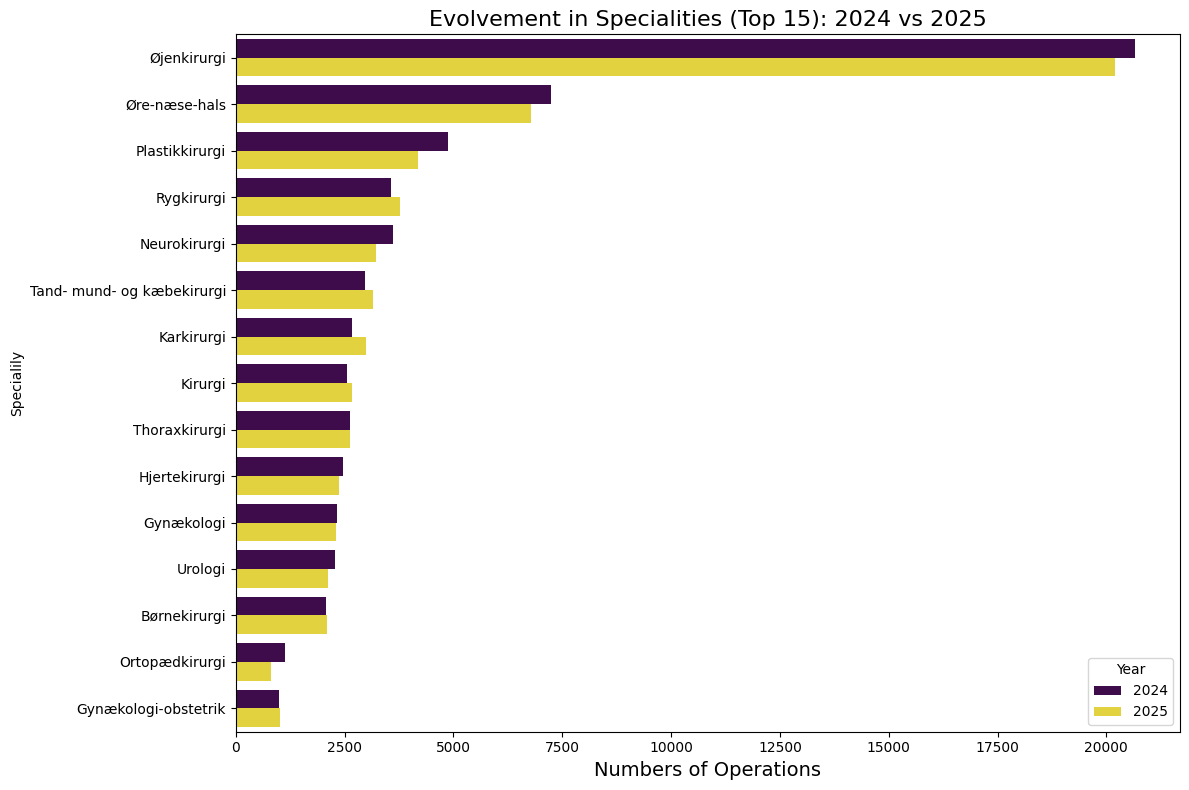

In [ ]:
# Vi tager de 15 største specialer for at holde det overskueligt
top_specialer = df_complete_wo['Speciale'].value_counts().nlargest(15).index
filtered_data = plot_data[plot_data['Speciale'].isin(top_specialer)]

#sorter det efter antal
filtered_data = filtered_data.sort_values('Antal', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=filtered_data, x='Antal', y='Speciale', hue='År', palette='viridis')

plt.title('Evolvement in Specialities (Top 15): 2024 vs 2025', fontsize=16)
plt.xlabel('Numbers of Operations', fontsize=14)
plt.ylabel('Specialily')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

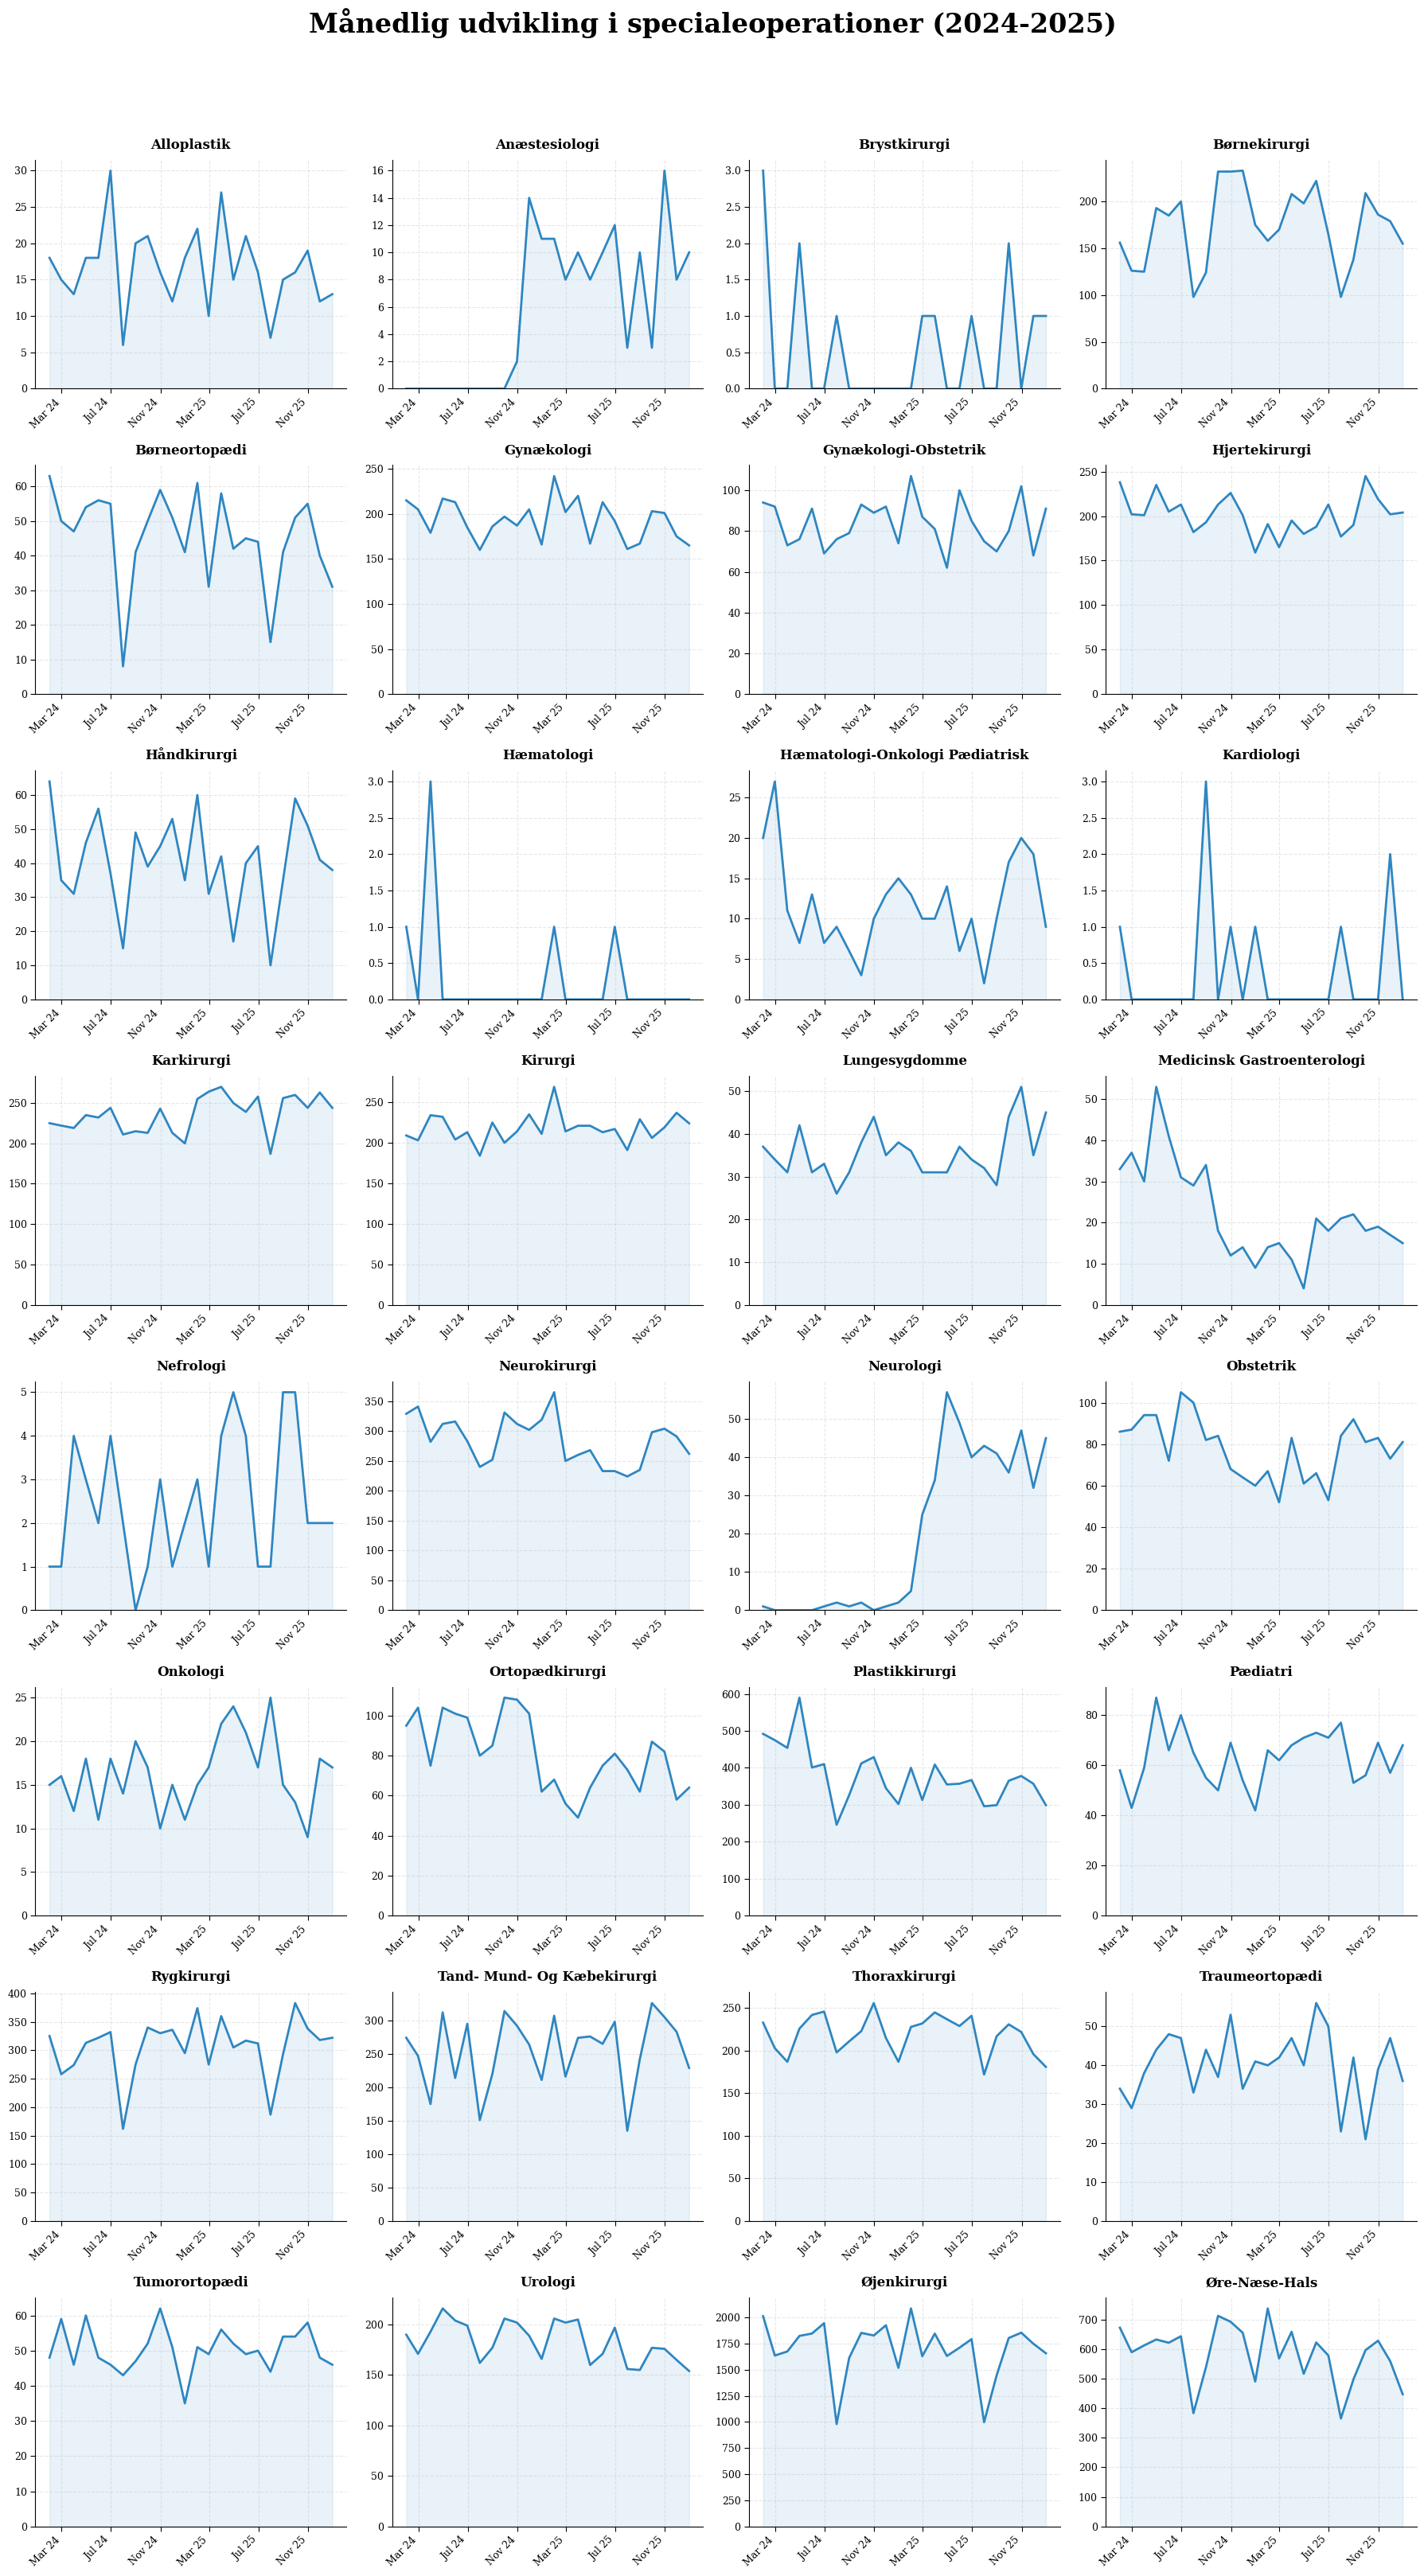

In [ ]:
# 1. Datapræparation
# Vi sikrer os at datoen er korrekt formateret og sat som index
df_complete_wo['Dato'] = pd.to_datetime(df_complete_wo['Dato'].astype(str).str.split(',').str[0])
df_indexed = df_complete_wo.set_index('Dato')

# 2. Gruppering og pivotering (Månedlig opsummering)
# 'ME' står for Month End. Vi tæller antallet af rækker (operationer) pr. måned
monthly_pivot = df_indexed.groupby('Speciale').resample('ME').size().unstack(level=0).fillna(0)

# Liste over specialer til loopet
specialer = sorted(monthly_pivot.columns)

# 3. Layout indstillinger
ncols = 4  
nrows = math.ceil(len(specialer) / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4), sharex=False) # sharex=False for bedre kontrol
axes = axes.flatten()

fig.suptitle("Månedlig udvikling i specialeoperationer (2024-2025)", 
             fontsize=24, y=1.01, family='serif', weight='bold')

# 4. Plot loop
for i, speciale in enumerate(specialer):
    ax = axes[i]
    
    # Plot selve linjen og skyggen under den
    ax.plot(monthly_pivot.index, monthly_pivot[speciale], color='#2E86C1', linewidth=2, label=speciale)
    ax.fill_between(monthly_pivot.index, monthly_pivot[speciale], color='#2E86C1', alpha=0.1)
    
    # Titler og styling af det enkelte subplot
    ax.set_title(speciale.title(), family='serif', size=12, weight='bold', pad=10)
    ax.grid(True, linestyle='--', alpha=0.4, color='#BDC3C7')
    ax.set_ylim(bottom=0)
    
    # Formatering af X-aksen (Datoer)
    # Vi viser hver 4. måned for at undgå overlap (Feb, Jun, Okt osv.)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) 
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y')) 
    
    # Rotation af dato-labels for læsbarhed
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', size=9, family='serif')
    plt.setp(ax.get_yticklabels(), size=9, family='serif')
    
    # Fjern top- og højre-ramme for et mere moderne udtryk
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4)

# 5. Oprydning: Fjern tomme felter hvis antallet af specialer ikke går op i 4
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Justering af layout så intet overlapper
# rect=[0, 0, 1, 0.98] sikrer at suptitle får plads i toppen
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_90525/2850433509.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


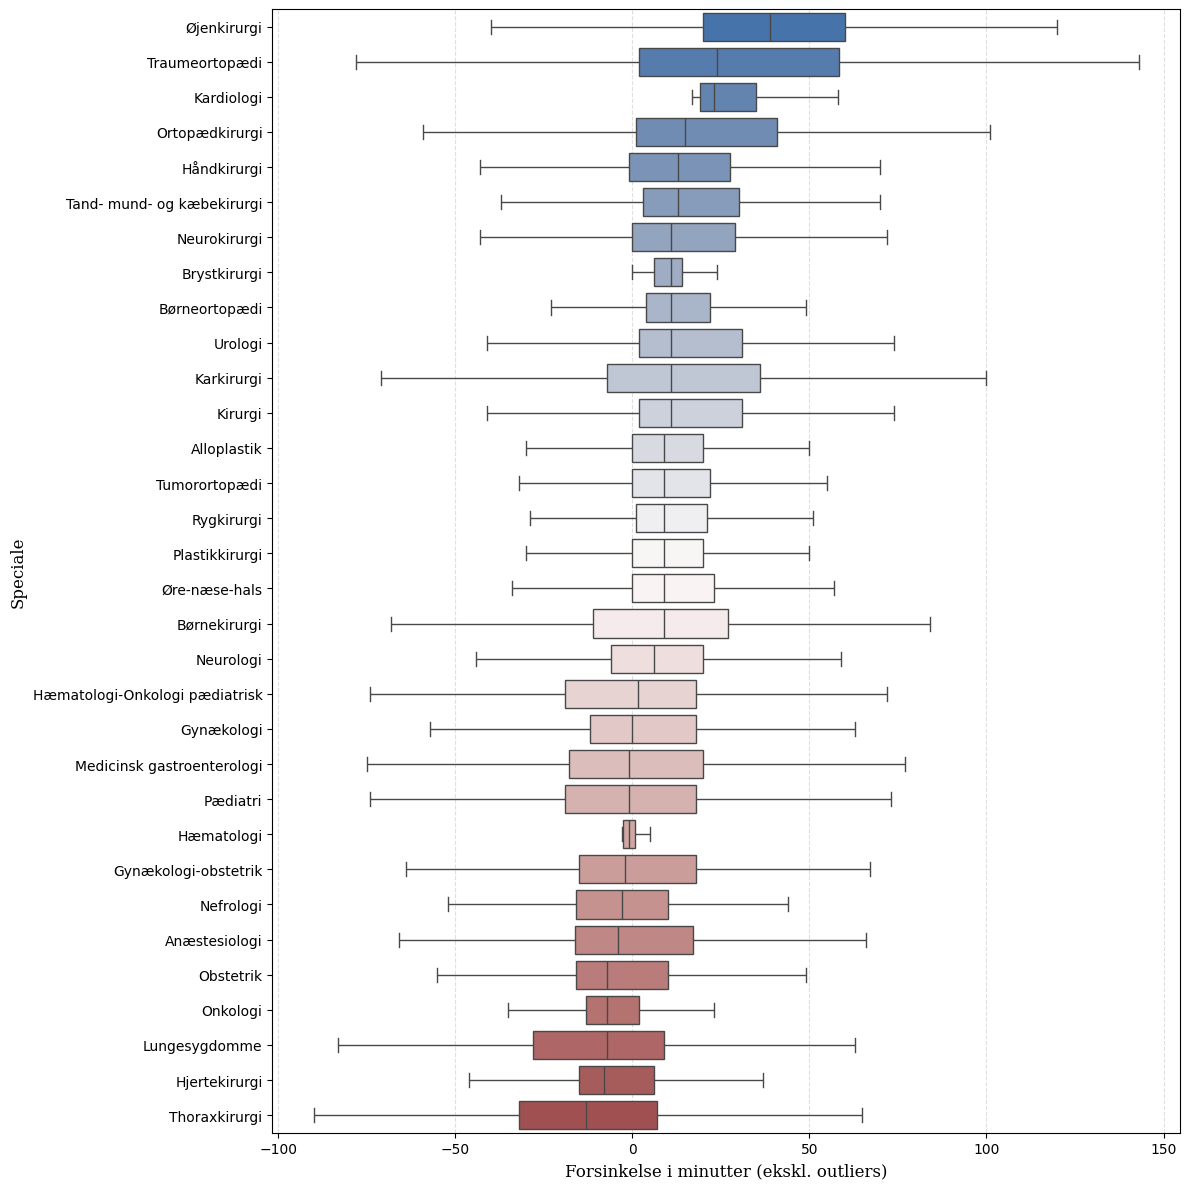

In [ ]:
# 1. Beregn rækkefølgen baseret på median (så de mest forsinkede er øverst)
order = df_complete_wo.groupby('Speciale')['Forsinkelse (minutter)'].median().sort_values(ascending=False).index

# 2. Opsæt figuren
# Da du har 33 specialer, skal højden være stor (f.eks. 12) for at teksten ikke overlapper
fig, ax1 = plt.subplots(figsize=(12, 12))

# 3. Lav boxplottet
sns.boxplot(
    data=df_complete_wo, 
    x='Forsinkelse (minutter)', 
    y='Speciale', 
    order=order, 
    palette='vlag', 
    ax=ax1, 
    showfliers=False # Fjerner de vilde prikker så vi kan se kasserne tydeligt
)

# 4. Styling og titler
#ax1.set_title('Præcision: Fordeling af forsinkelser pr. speciale', fontsize=18, weight='bold', family='serif', pad=20)
ax1.set_xlabel('Forsinkelse i minutter (ekskl. outliers)', fontsize=12, family='serif')
ax1.set_ylabel('Speciale', fontsize=12, family='serif')

# Tilføj en rød lodret streg ved 0 (perfekt præcision)
#ax1.axvline(0, color='red', linestyle='--', alpha=0.6, label='Planlagt tid')

# Gør grid-linjerne tydelige på x-aksen for nemmere aflæsning
ax1.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
def count_outliers(group):
    Q1 = group['Forsinkelse (minutter)'].quantile(0.25)
    Q3 = group['Forsinkelse (minutter)'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    # Vi tæller kun dem over øvre grænse, da de er de mest kritiske forsinkelser
    return (group['Forsinkelse (minutter)'] > upper_bound).sum()

# Gruppér og tæl
outlier_counts = df_complete_wo.groupby('Speciale').apply(count_outliers).reset_index()
outlier_counts.columns = ['Speciale', 'Antal Outliers']

# Tilføj total antal operationer for at få en procentdel
total_counts = df_complete_wo['Speciale'].value_counts().reset_index()
total_counts.columns = ['Speciale', 'Total n']

outlier_summary = pd.merge(outlier_counts, total_counts, on='Speciale')
outlier_summary['Outlier pct'] = (outlier_summary['Antal Outliers'] / outlier_summary['Total n']) * 100

# Sortér efter flest outliers
outlier_summary = outlier_summary.sort_values(by='Antal Outliers', ascending=False)
print(outlier_summary.head(10))

                      Speciale  Antal Outliers  Total n  Outlier pct
31               Øre-næse-hals            1012    14010     7.223412
30                 Øjenkirurgi             898    40868     2.197318
24                  Rygkirurgi             737     7346    10.032671
22              Plastikkirurgi             559     9077     6.158422
13                     Kirurgi             513     5225     9.818182
7                Hjertekirurgi             505     4837    10.440356
29                     Urologi             415     4399     9.433962
25  Tand- mund- og kæbekirurgi             400     6125     6.530612
17                Neurokirurgi             390     6842     5.700088
12                  Karkirurgi             353     5662     6.234546


/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_90525/3484755023.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outlier_counts = df_complete_wo.groupby('Speciale').apply(count_outliers).reset_index()


In [ ]:
speciale1 = "Øjenkirurgi"

df1 = df_complete_wo[df_complete_wo['Speciale'] == speciale1]
df1['Akut case (J/N)'].value_counts()


Akut case (J/N)
Nej    37398
Ja      3470
Name: count, dtype: int64

In [ ]:
df_complete_wo['Akut case (J/N)']

0         Nej
1         Nej
2         Nej
3         Nej
4         Nej
         ... 
133153    Nej
133154    Nej
133155    Nej
133156    Nej
133157    Nej
Name: Akut case (J/N), Length: 133158, dtype: object

In [ ]:
for speciale in df_complete_wo['Speciale'].unique():
    df_speciale = df_complete_wo[df_complete_wo['Speciale'] == speciale]
    
    # Brug len() eller .shape[0] for at få selve antallet
    antal_ja = len(df_speciale[df_speciale['Akut case (J/N)'] == 'Ja'])
    antal_nej = len(df_speciale[df_speciale['Akut case (J/N)'] == 'Nej'])
    antal_total = len(df_speciale)
    
    print(f"Speciale: {speciale}")
    print(f"Ratio: {(antal_ja / antal_total)*100 if antal_total > 0 else 'N/A'}")
    print("-" * 20)

Speciale: Øre-næse-hals
Ratio: 12.84796573875803
--------------------
Speciale: Plastikkirurgi
Ratio: 9.760934229370937
--------------------
Speciale: Tand- mund- og kæbekirurgi
Ratio: 11.738775510204082
--------------------
Speciale: Øjenkirurgi
Ratio: 8.490750709601643
--------------------
Speciale: Børnekirurgi
Ratio: 16.854741896758703
--------------------
Speciale: Ortopædkirurgi
Ratio: 37.38414006179197
--------------------
Speciale: Børneortopædi
Ratio: 3.3057851239669422
--------------------
Speciale: Karkirurgi
Ratio: 34.72271282232427
--------------------
Speciale: Thoraxkirurgi
Ratio: 24.97147204260175
--------------------
Speciale: Hjertekirurgi
Ratio: 35.31114327062229
--------------------
Speciale: Urologi
Ratio: 25.414867015230737
--------------------
Speciale: Håndkirurgi
Ratio: 6.570841889117044
--------------------
Speciale: Kirurgi
Ratio: 45.014354066985646
--------------------
Speciale: Neurokirurgi
Ratio: 47.924583455130076
--------------------
Speciale: Pædiatri
R

In [ ]:
# 1. Tæl J og N pr. speciale og beregn ratio
akut_tabel = df_complete_wo.groupby('Speciale')['Akut case (J/N)'].value_counts(normalize=True).unstack(fill_value=0) * 100

# 2. Tilføj total antal (n) så man kan se volumen
akut_tabel['Total n'] = df_complete_wo.groupby('Speciale').size()

# 3. Sortér efter højeste ratio af akutte cases
akut_tabel = akut_tabel.sort_values(by='Ja', ascending=False)

# 4. Pæn navngivning af kolonner
akut_tabel.columns = ['Planlagt Ratio (%)', 'Akut Ratio (%)', 'Total Volumen (n)']
print(akut_tabel.head(10))

                            Planlagt Ratio (%)  Akut Ratio (%)  \
Speciale                                                         
Anæstesiologi                        96.323529        3.676471   
Neurologi                            88.362069       11.637931   
Obstetrik                            68.108974       31.891026   
Medicinsk gastroenterologi           67.910448       32.089552   
Kardiologi                           66.666667       33.333333   
Traumeortopædi                       53.989637       46.010363   
Gynækologi-obstetrik                 52.542373       47.457627   
Neurokirurgi                         47.924583       52.075417   
Nefrologi                            45.762712       54.237288   
Kirurgi                              45.014354       54.985646   

                            Total Volumen (n)  
Speciale                                       
Anæstesiologi                             136  
Neurologi                                 464  
Obstetrik      

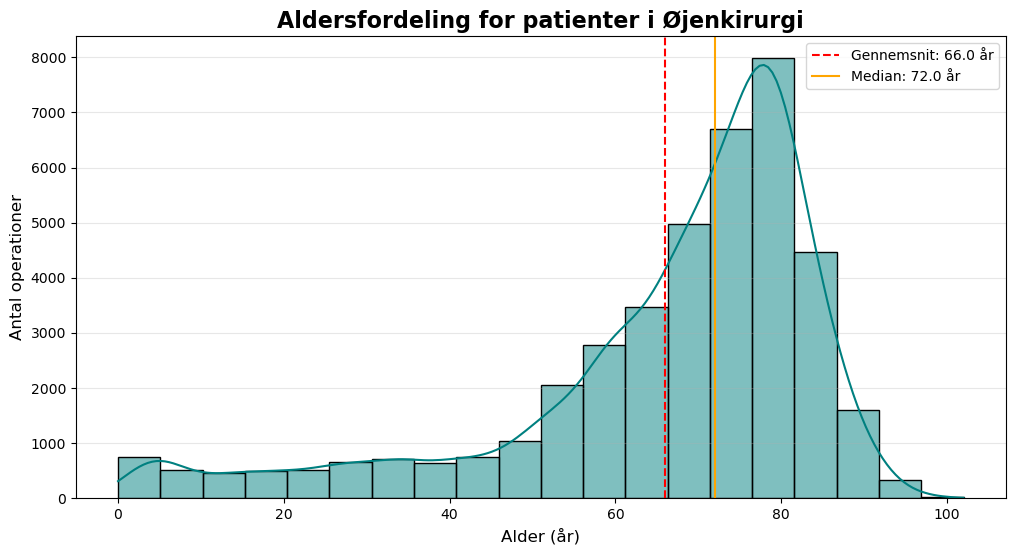

Statistik for Øjenkirurgi (n=40868):
Yngste patient: 0 år
Ældste patient: 102 år
Typisk alder (median): 72.0 år


In [51]:
# 1. Filtrér data så vi kun ser på Øjenkirurgi
df_øjen = df_complete[df_complete['Speciale'] == 'Øjenkirurgi']

# 2. Opsæt figuren
plt.figure(figsize=(12, 6))

# 3. Lav et histogram med en tæthedskurve (KDE)
sns.histplot(df_øjen['Patient Alder'], bins=20, kde=True, color='teal', edgecolor='black')

# 4. Tilføj statistiske linjer (Gennemsnit og Median)
mean_age = df_øjen['Patient Alder'].mean()
median_age = df_øjen['Patient Alder'].median()

plt.axvline(mean_age, color='red', linestyle='--', label=f'Gennemsnit: {mean_age:.1f} år')
plt.axvline(median_age, color='orange', linestyle='-', label=f'Median: {median_age:.1f} år')

# 5. Styling
plt.title('Aldersfordeling for patienter i Øjenkirurgi', fontsize=16, weight='bold')
plt.xlabel('Alder (år)', fontsize=12)
plt.ylabel('Antal operationer', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Print hurtig statistik
print(f"Statistik for Øjenkirurgi (n={len(df_øjen)}):")
print(f"Yngste patient: {df_øjen['Patient Alder'].min()} år")
print(f"Ældste patient: {df_øjen['Patient Alder'].max()} år")
print(f"Typisk alder (median): {median_age} år")

/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_90525/3451504359.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


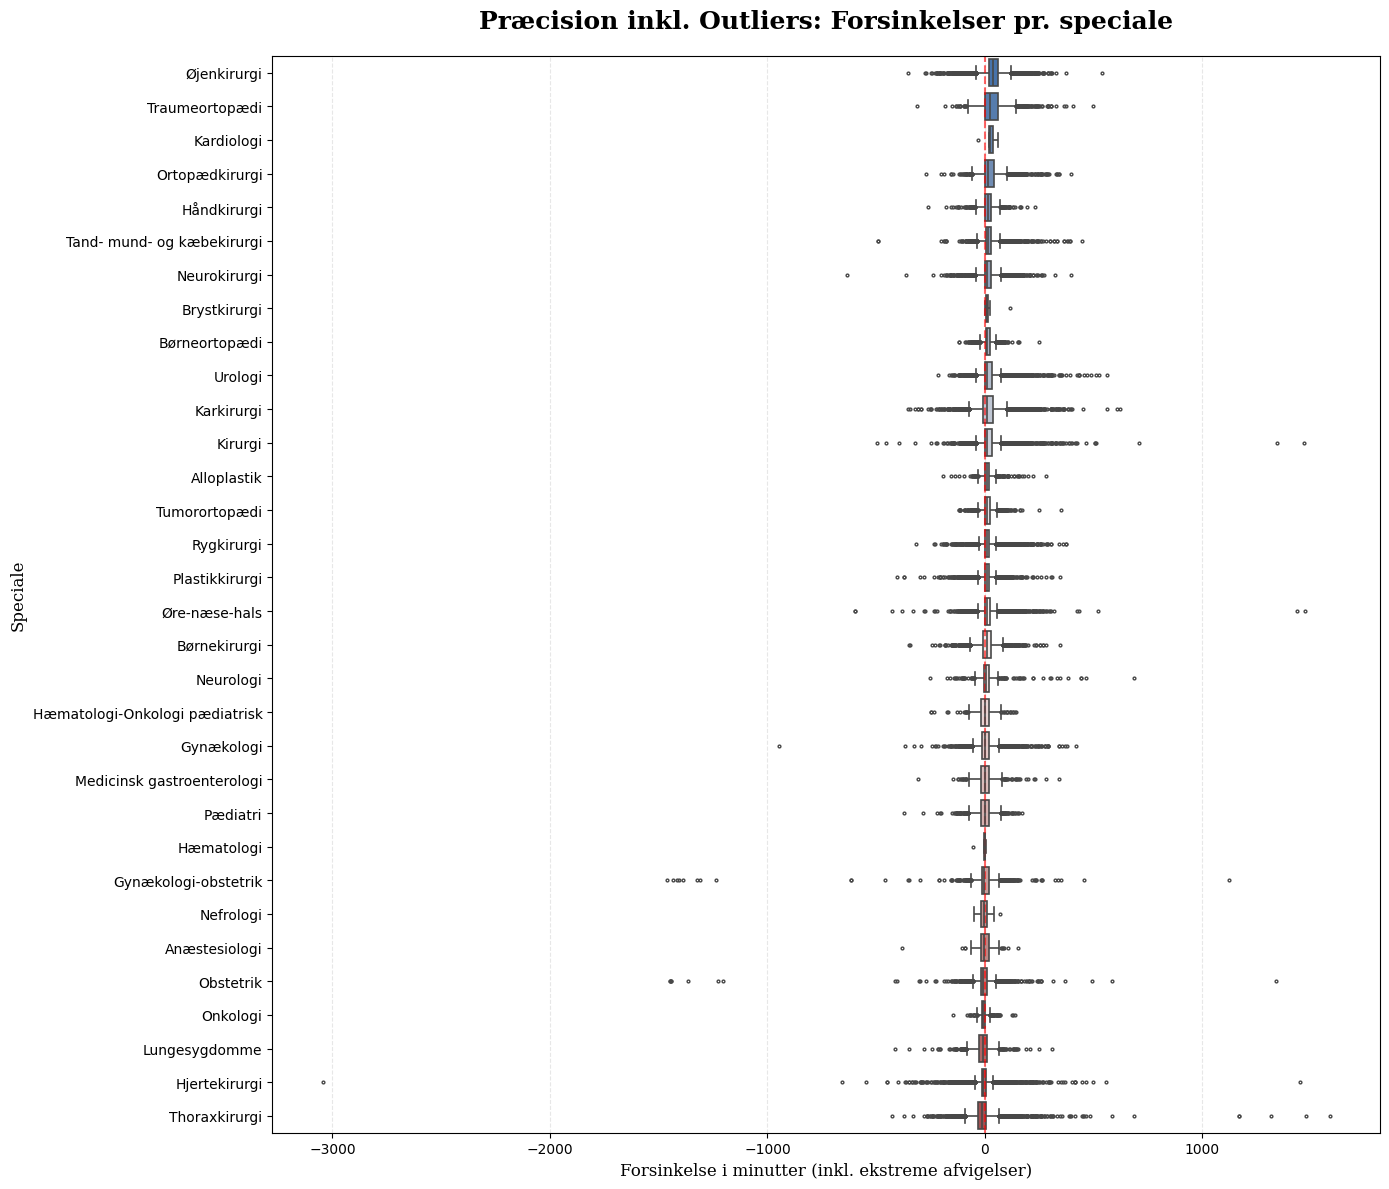

In [ ]:
# 1. Beregn rækkefølgen baseret på median
order = df_complete_wo.groupby('Speciale')['Forsinkelse (minutter)'].median().sort_values(ascending=False).index

# 2. Opsæt figuren (vi gør den lidt bredere for at give plads til outliers)
fig, ax1 = plt.subplots(figsize=(14, 12))

# 3. Lav boxplottet MED outliers
sns.boxplot(
    data=df_complete_wo, 
    x='Forsinkelse (minutter)', 
    y='Speciale', 
    order=order, 
    palette='vlag', 
    ax=ax1, 
    showfliers=True,  # Her beholder vi outliers
    fliersize=2,      # Mindre prikker for bedre overblik
    linewidth=1.2,
    whis=1.5          # Standard definition af outliers
)

# 4. Styling og titler
ax1.set_title('Præcision inkl. Outliers: Forsinkelser pr. speciale', fontsize=18, weight='bold', family='serif', pad=20)
ax1.set_xlabel('Forsinkelse i minutter (inkl. ekstreme afvigelser)', fontsize=12, family='serif')
ax1.set_ylabel('Speciale', fontsize=12, family='serif')

# Tilføj en rød lodret streg ved 0
ax1.axvline(0, color='red', linestyle='--', alpha=0.6, label='Planlagt tid')

# Sæt et fornuftigt limit på x-aksen hvis der er fejl-indtastninger (f.eks. 1000 min)
# ax1.set_xlim(-60, 600) 

ax1.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Forberedelse af data
# Vi filtrerer ekstreme fejl-indtastninger fra (f.eks. hvis forsinkelse er 0 eller negativ, afhængig af data)
# Vi fokuserer på de 10 specialer med flest forsinkelser for at gøre plottet overskueligt
top_specialer = df_complete_wo.groupby('Speciale')['Forsinkelse (minutter)'].median().nlargest(33).index
df_plot = df_complete_wo[df_complete_wo['Speciale'].isin(top_specialer)]


# --- PLOT 1: Fordeling af forsinkelser pr. speciale (Boxplot) ---
sns.boxplot(data=df_plot, x='Forsinkelse (minutter)', y='Speciale', 
            palette='vlag', ax=ax1, showfliers=False) # showfliers=False fjerner ekstreme outliers for bedre overblik
ax1.set_title('Præcision: Fordeling af forsinkelser (Top 10 specialer efter median)', fontsize=16, weight='bold', family='serif')
ax1.set_xlabel('Forsinkelse i minutter (Ekskl. ekstreme outliers)', fontsize=12)
ax1.grid(axis='x', linestyle='--', alpha=0.6)
# --- PLOT 2: Hvad er årsagen til forsinkelserne? ---
# Vi tæller de hyppigste årsager
causes = df_complete_wo['Forsinkelsesårsag'].value_counts().nlargest(10)
sns.barplot(x=causes.values, y=causes.index, palette='viridis', ax=ax2)
ax2.set_title('De 10 hyppigste årsager til forsinkelse', fontsize=16, weight='bold', family='serif')
ax2.set_xlabel('Antal hændelser', fontsize=12)
ax2.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Beregn en hurtig "Præcisions-score"
total_cases = len(df_complete_wo)
on_time_cases = len(df_complete_wo[df_complete_wo['Forsinkelse (minutter)'] <= 30]) # 30 min buffer
precision_pct = (on_time_cases / total_cases) * 100

print(f"Samlet præcision: {precision_pct:.1f}% af alle operationer starter inden for 30 minutter af planlagt tid.")

/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_90525/1669433109.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Forsinkelse (minutter)', y='Speciale',


NameError: name 'ax2' is not defined

In [ ]:
# Beregn median forsinkelse pr. speciale
median_delay = df_complete_wo.groupby('Speciale')['Forsinkelse (minutter)'].median().reset_index()

# Beregn også antal operationer (n) for at give tabellen kontekst
counts = df_complete_wo['Speciale'].value_counts().reset_index()
counts.columns = ['Speciale', 'Antal operationer (n)']

# Merge de to ting sammen
result_table = pd.merge(median_delay, counts, on='Speciale')

# Sortér så de mest forsinkede står øverst
result_table = result_table.sort_values(by='Forsinkelse (minutter)', ascending=False).reset_index(drop=True)

# Omdøb kolonnen for overskuelighed
result_table.columns = ['Speciale', 'Median Forsinkelse (min)', 'Volumen (n)']

# Vis tabellen
print(result_table)

                          Speciale  Median Forsinkelse (min)  Volumen (n)
0                      Øjenkirurgi                      39.0        40868
1                   Traumeortopædi                      24.0          965
2                       Kardiologi                      23.0            9
3                   Ortopædkirurgi                      15.0         1942
4                      Håndkirurgi                      13.0          974
5       Tand- mund- og kæbekirurgi                      13.0         6125
6                     Neurokirurgi                      11.0         6842
7                     Brystkirurgi                      11.0           13
8                    Børneortopædi                      11.0         1089
9                          Urologi                      11.0         4399
10                      Karkirurgi                      11.0         5662
11                         Kirurgi                      11.0         5225
12                     Alloplastik    

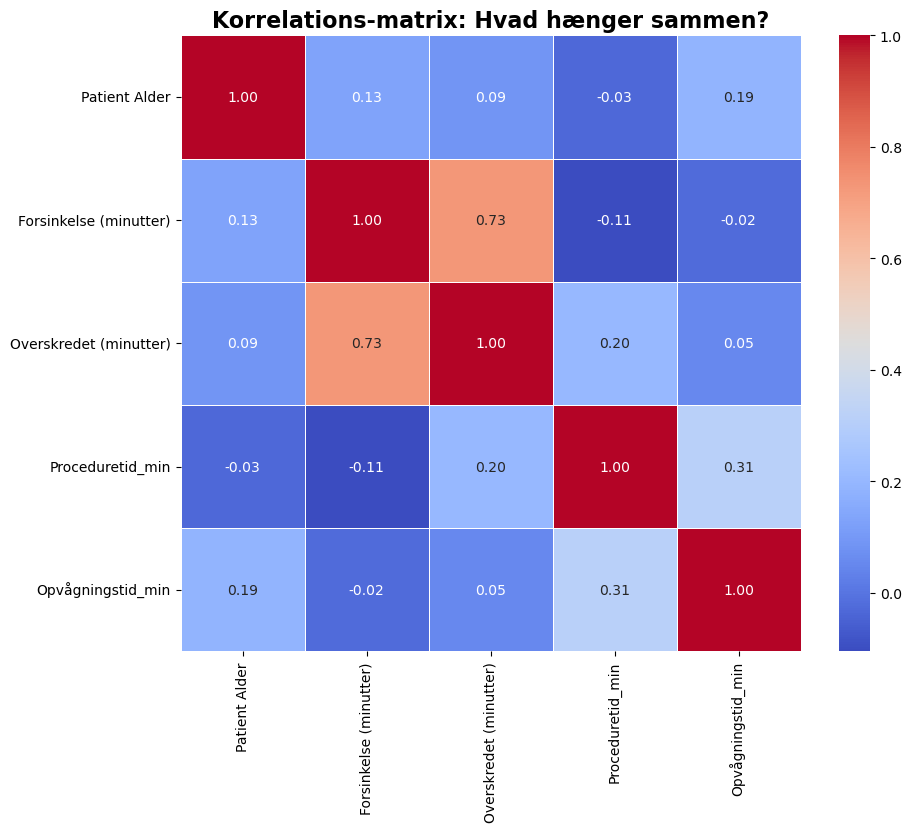

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vi skal først beregne varighederne i minutter for at kunne korrelere dem
df_complete_wo['Opvågningstid_min'] = (df_complete_wo['Klar til udskrivelse efter opvågning'] - df_complete_wo['I opvågning']).dt.total_seconds() / 60
df_complete_wo['Proceduretid_min'] = (df_complete_wo['Procedure slut'] - df_complete_wo['Procedure start']).dt.total_seconds() / 60

# Vælg de numeriske kolonner vi vil tjekke
cols_to_corr = ['Patient Alder', 'Forsinkelse (minutter)', 'Overskredet (minutter)', 'Proceduretid_min', 'Opvågningstid_min']
corr_matrix = df_complete_wo[cols_to_corr].corr()

# Lav Heatmappet
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korrelations-matrix: Hvad hænger sammen?', fontsize=16, weight='bold')
plt.show()

## ny section

In [1]:
df_complete_wo["total_or_time"] = (
    df_complete_wo["prep_time"]
    + df_complete_wo["surgery_time"]
    + df_complete_wo["recovery_room_time"]
    + df_complete_wo["cleaning_time"]
)

df_complete_wo["or_efficiency"] = (
    df_complete_wo["surgery_time"] / df_complete_wo["total_or_time"]
)

NameError: name 'df_complete_wo' is not defined

In [ ]:
fig = px.box(
    df_complete_wo,
    x="Speciale",
    y="or_efficiency",
    title="OR efficiency pr speciale"
)

fig.update_xaxes(tickangle=45)

fig.show()

In [ ]:
df_complete_wo["start_hour"] = df_complete_wo["Procedure start"].dt.hour

ops_per_hour = (
    df_complete_wo.groupby("start_hour")
    .size()
    .reset_index(name="operations")
)

In [ ]:


fig = px.bar(
    ops_per_hour,
    x="start_hour",
    y="operations",
    title="Antal operationer startet pr time"
)

fig.show()

## network

In [ ]:
import networkx as nx

G = nx.Graph()

for _, row in df_complete.iterrows():

    staff_present = [c for c in staff_cols if pd.notna(row[c])]
    resources_present = [c for c in resource_cols if pd.notna(row[c])]

    for s in staff_present:
        for r in resources_present:
            G.add_edge(s, r)

In [ ]:
nx.degree_centrality(G)

{'Staff.Gulvassistent': 0.8436018957345972,
 'Ressource.Diatermiapparat': 0.12322274881516589,
 'Staff.Operationssygeplejerske ': 0.8578199052132702,
 'Staff.Preprocedure Nurse': 0.8199052132701422,
 'Staff.Primær': 0.8720379146919433,
 'Staff.Ekstra primær kirurg': 0.7156398104265403,
 'Staff.Læge': 0.6966824644549764,
 'Staff.Assistent': 0.6729857819905214,
 'Staff.Supervisor': 0.5781990521327015,
 'Ressource.Boremaskine konsol': 0.09004739336492892,
 'Ressource.Piezo boremaskine TMK': 0.07582938388625593,
 'Staff.Steril assistance': 0.07582938388625593,
 'Ressource.Zimmer Dermatome': 0.08530805687203792,
 'Ressource.Vitrector': 0.07109004739336494,
 'Ressource.Bronchoskop': 0.07582938388625593,
 'Ressource.Erbe Diatermi': 0.09004739336492892,
 'Staff.Recovery Nurse': 0.8436018957345972,
 'Ressource.COP2910   Specialbakke karkirurgi': 0.06635071090047394,
 'Ressource.Blodtomhedsapparat': 0.08530805687203792,
 'Staff.Operationstekniker': 0.2132701421800948,
 'Ressource.Flexibelt bronc

In [ ]:
nx.algorithms.community.greedy_modularity_communities(G)

[frozenset({'Ressource.312.393   Hammer og mejsel',
            'Ressource.A:R:C: LASER',
            'Ressource.Airseal insufflator',
            'Ressource.Argon Beamer',
            'Ressource.Artroskop - Stryker',
            'Ressource.Artroskopisøjle',
            'Ressource.B-scanner',
            'Ressource.BK Medical Flex Focus 800 (robotprobe)',
            'Ressource.BMAC-centrifuge',
            'Ressource.Beaver Blade And Handle',
            'Ressource.Benchbord',
            'Ressource.Blodtryksapparat',
            'Ressource.Blærescanner',
            'Ressource.Body-jet',
            'Ressource.Boremaskine konsol BAHA',
            'Ressource.Bronchoscope Flexible',
            'Ressource.C-Bue mini',
            'Ressource.CO2 Laser',
            'Ressource.COP2707   Knoglemølle',
            'Ressource.COP2910   Specialbakke karkirurgi',
            'Ressource.COP2918   Håndkirurgi',
            'Ressource.COP3589   A O bøjejern rekonstruktionsskinner',
            

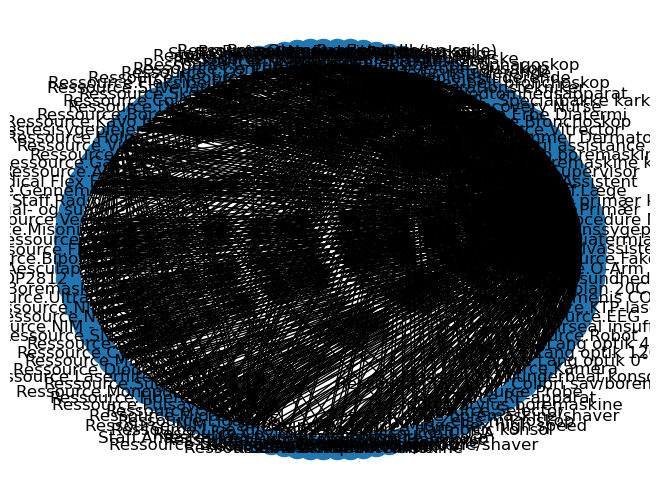

In [ ]:
pos = nx.circular_layout(G)

nx.draw(G, pos, with_labels=True)

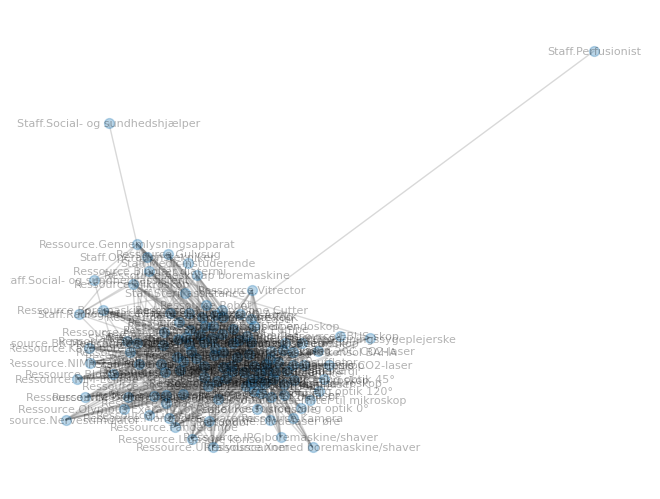

In [ ]:
# Skift pos til dette:
pos = nx.kamada_kawai_layout(G)

# Tegn med mindre gennemsigtige streger (alpha)
nx.draw(G, pos, with_labels=True, node_size=50, font_size=8, edge_color='gray', alpha=0.3)

In [ ]:
from pyvis.network import Network
import networkx as nx

# 1. Opret Pyvis-netværket
# 'notebook=True' hvis du bruger Jupyter, ellers False
net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", select_menu=True, filter_menu=True)

# 2. Vi genbruger din graf 'G' fra før (eller G_filtered for bedre performance)
# Vi tilføjer noder og kanter fra din NetworkX-graf
net.from_nx(G)

# 3. Gør det lækkert: Tilføj "Physics" så noderne hopper og danser lidt
net.toggle_physics(True)

# 4. Gem og åbn i din browser
net.show("hospital_network.html", notebook=False)

hospital_network.html


In [ ]:
from pyvis.network import Network
import networkx as nx

# 1. Brug 'notebook=False' for at undgå problemer med visning i din editor
# Vi tilføjer cdn_resources='remote' for at sikre, at den henter JavaScript korrekt
net = Network(
    height="750px", 
    width="100%", 
    bgcolor="#222222", 
    font_color="white",
    cdn_resources='remote'
)

# 2. Gør noderne mere synlige og tilføj data
for node in G.nodes():
    # Vi giver dem en fast størrelse så de ikke forsvinder
    G.nodes[node]['size'] = 25 
    if node in staff_cols:
        G.nodes[node]['color'] = '#3498DB' # Blå
        G.nodes[node]['label'] = str(node)
    else:
        G.nodes[node]['color'] = '#2ECC71' # Grøn
        G.nodes[node]['label'] = str(node)

# 3. Importér fra din NetworkX-graf
net.from_nx(G)

# 4. Tving fysikken til at sprede noderne (vigtigt mod "hårboller")
net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=250)

# 5. GEM FILEN (Tjek din mappe for denne fil bagefter!)
net.write_html("mit_netvaerk.html")

print("Færdig! Find filen 'mit_netvaerk.html' i din mappe og åbn den i Chrome eller Edge.")

Færdig! Find filen 'mit_netvaerk.html' i din mappe og åbn den i Chrome eller Edge.


In [ ]:
threshold = 50

G_small = nx.Graph()

for (s, r), w in edge_weights.items():
    if w > threshold:
        G_small.add_edge(s, r, weight=w)

In [ ]:
import networkx as nx
import plotly.graph_objects as go

# 1. Vælg de stærkeste forbindelser
top_edges = sorted(edge_weights.items(), key=lambda x: x[1], reverse=True)[:40]

G_small = nx.Graph()
for (s, r), w in top_edges:
    G_small.add_edge(s, r, weight=w)

# 2. Layout
pos = nx.spring_layout(G_small, seed=42)

# 3. Edge trace
edge_x = []
edge_y = []

for u, v in G_small.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode="lines",
    hoverinfo="none",
    line=dict(width=0.7, color="gray")
)

# 4. Node trace
node_x = []
node_y = []
node_text = []
node_color = []
node_size = []

for node in G_small.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

    degree = G_small.degree(node)

    if "Staff" in node:
        node_color.append("steelblue")
    else:
        node_color.append("darkorange")

    node_size.append(10 + degree * 3)
    node_text.append(f"{node}<br>Degree: {degree}")

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers+text",
    hoverinfo="text",
    text=[n if G_small.degree(n) >= 2 else "" for n in G_small.nodes()],
    textposition="top center",
    textfont=dict(size=10),
    marker=dict(
        color=node_color,
        size=node_size,
        line=dict(width=1, color="black")
    ),
    hovertext=node_text
)

# 5. Figur
fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title="Staff–ressource netværk (top 40 stærkeste forbindelser)",
        showlegend=False,
        hovermode="closest",
        margin=dict(l=20, r=20, t=50, b=20),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor="white"
    )
)

fig.show()